<div style="background-color: steelblue; padding: 10px; border-radius: 5px;">
    <p style="margin: 10;"></p>
    <h1 style="text-align: center; margin: 0; font-weight: bold; color: white;">SWOT Ocean Model Intercomparison Project : EORCA12-ERA5v1 Test Case</h1>
    <p style="margin: 10;"></p>
</div>



## 📦**Imports** 

In [1]:
%%time

##################################
#Imports

from datetime import datetime
import s3fs
import xarray as xr
import pyinterp
#from widetrax import DataPreprocessing as dp
#from widetrax import Spectra as sp
import numpy as np
import json
from watermark import watermark
import time
import platform
#import tempfile
from shapely.geometry import shape, box
from shapely import geometry
import geopandas as gpd

CPU times: user 609 ms, sys: 118 ms, total: 727 ms
Wall time: 731 ms


## 🧮 **Required variables**

In [2]:

season="JFM"
s3_folder ="s3://project-moi-swot-omip/GLO36V1" # Do not write /!!!!!!
endpoint_url =  "https://minio.dive.edito.eu/"




## 🔍 **Check the S3 Endpoint**  

In [3]:
s3_folder ="s3://project-moi-swot-omip/GLO36V1" # Do not write /!!!!!!
endpoint_url =  "https://minio.dive.edito.eu/"
fs = s3fs.S3FileSystem(anon=True,endpoint_url=endpoint_url)
# List contents of the bucket
bucket_name = 's3://project-moi-swot-omip/GLO36V1'
contents = fs.ls(bucket_name)
print("Bucket contents:")
for item in contents:
    print(item)

Bucket contents:
project-moi-swot-omip/GLO36V1/cycle_.keep
project-moi-swot-omip/GLO36V1/cycle_008
project-moi-swot-omip/GLO36V1/cycle_009
project-moi-swot-omip/GLO36V1/cycle_010
project-moi-swot-omip/GLO36V1/cycle_011
project-moi-swot-omip/GLO36V1/cycle_012
project-moi-swot-omip/GLO36V1/cycle_013
project-moi-swot-omip/GLO36V1/cycle_014
project-moi-swot-omip/GLO36V1/cycle_015
project-moi-swot-omip/GLO36V1/cycle_016
project-moi-swot-omip/GLO36V1/cycle_017
project-moi-swot-omip/GLO36V1/cycle_018
project-moi-swot-omip/GLO36V1/cycle_019
project-moi-swot-omip/GLO36V1/cycle_020
project-moi-swot-omip/GLO36V1/cycle_021
project-moi-swot-omip/GLO36V1/cycle_022
project-moi-swot-omip/GLO36V1/cycle_023
project-moi-swot-omip/GLO36V1/cycle_024
project-moi-swot-omip/GLO36V1/cycle_025
project-moi-swot-omip/GLO36V1/cycle_026


## 📊 **Load datasets and compute Wavenumber spectra**

## 🔄 **Identify the cycle numbers within the specified time range** 

In [4]:
import DataPreprocessing as dp0

if season=="JFM":    
    start_date = "01012024" # "DDMMYYYY"
    end_date ="31032024"
elif season=="JAS":
    start_date = "01072024" # "DDMMYYYY"
    end_date ="30092024"

if season =="JFM":
    file_path = "https://minio.lab.dive.edito.eu/project-meom-ige/cycles_periods.csv" # works only for winter period
elif season =="JAS":
    file_path = "time_ranges.csv"  # for summer

matching_cycles = dp0.get_matching_cycles(file_path, start_date, end_date)

def formater_numeros_concis(liste_numeros):
  return [str(numero).zfill(3) for numero in liste_numeros]
    
matching_cycles = formater_numeros_concis(matching_cycles)
matching_cycles

['008', '009', '010', '011', '012', '013']

In [5]:
from shapely.geometry import shape, box

with open("mostly_ocean_boxes_filtered.geojson") as f:
    data = json.load(f)

feature=data["features"][0]
poly = shape(feature["geometry"])

#lon_min, lat_min, lon_max, lat_max
area = list(poly.bounds)
area[0]=(area[0] + 360) % 360
area[2]=(area[2] + 360) % 360
area = tuple(area)
print(area)


(180.0, -70.0, 190.0, -60.0)


In [6]:
def get_half_orbits_intersect(bbox):
    """Get half orbits that intersect a bounding box.
    Parameters
    ----------
    bbox:
        the bounding box

    Returns
    -------
     gpd.GeoDataFrame:
        A Geopandas dataframe containing intersecting half orbits numbers and geometries
    """
    swath_geometries = gpd.read_file(GEOMETRIES_FILE)

    bbox_polygon = geometry.box(*bbox)

    def _filter_intersect(row, polygon):
        half_orbit_polygon = row.geometry
        return polygon.intersects(half_orbit_polygon)

    select = swath_geometries.apply(_filter_intersect, polygon=bbox_polygon, axis=1)
    return swath_geometries[select]


def swath_search(lsw, lNE, latsw, latNE, GEOMETRIES_FILE):
    
    lon_range = lsw, lNE
    lat_range = latsw, latNE
    bbox = [lon_range[0], lat_range[0], lon_range[1], lat_range[1]]
    plot_extent = [lon_range[0], lon_range[1], lat_range[0], lat_range[1]]   
    swath_geoms = get_half_orbits_intersect(bbox)
    half_orbits = list(swath_geoms['pass_number'])
    
    return np.transpose(half_orbits)

    
import s3fs
from datetime import datetime

import s3fs
from datetime import datetime
import re

def find_listdata(matching_cycles, bucket, pass_numbers, start_date, end_date):
    """
    Find .nc files in S3 matching cycles, pass numbers, and months.

    Parameters:
        matching_cycles (list[int]): List of cycle numbers to search.
        prefix (str): S3 folder prefix (e.g., 'swotce').
        bucket (str): S3 bucket name.
        pass_numbers (list[int]): List of allowed pass numbers.
        start_date (str): Start date in format 'ddmmyyyy'.
        end_date (str): End date in format 'ddmmyyyy'.

    Returns:
        list_files (list[str]): List of S3 keys that match the filters.
    """
    # Convert start/end dates to month integers
    m1 = datetime.strptime(start_date, "%d%m%Y").month
    m2 = datetime.strptime(end_date, "%d%m%Y").month

    # Initialize S3 filesystem
    fs = s3fs.S3FileSystem(anon=True, endpoint_url=endpoint_url)  # assumes AWS credentials are set in environment or ~/.aws/credentials
    list_files = []

    for cycle_number in matching_cycles:
        # Construct the S3 folder path
        s3_folder = f"{bucket}/cycle_{cycle_number}/"
        
        # Recursively find all .nc files
        all_files = fs.glob(s3_folder + "**/*.nc")  # ** for recursive search

        for filename in all_files:
            # Extract pass number safely (adjust indices if needed)
            try:
                passnumber = int(filename[-15:-12])
            except ValueError:
                continue  # skip if pass number parsing fails

            # Extract date from filename using regex
            match = re.search(r'(\d{8})', filename)
            if not match:
                continue  # skip files without a date
            date_str = match.group(1)
            try:
                month = datetime.strptime(date_str, "%Y%m%d").month
            except ValueError:
                continue  # skip if date parsing fails

            # Apply filters
            if (month in range(m1, m2+1)) and (passnumber in pass_numbers):
                print(filename)
                list_files.append(filename)

    print(f"{len(list_files)} files found")
    return list_files



In [51]:
print(area)

(-180.0, -70.0, -170.0, -60.0)


In [7]:
from shapely import geometry
prefix='GLO36V1'


lon_min, lat_min, lon_max, lat_max = area
#lon_min=-lon_min
phase = 'science'
GEOMETRIES_FILE = f'KaRIn_2kms_{phase}_geometries.geojson'
pass_numbers = swath_search(lon_min, lon_max, lat_min, lat_max, GEOMETRIES_FILE)
list_files=find_listdata(matching_cycles, bucket_name, pass_numbers, start_date, end_date)




project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_497_20240101T000706_20240101T005832_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_510_20240101T111555_20240101T120721_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_520_20240101T195023_20240101T204149_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_522_20240101T213316_20240101T222443_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_538_20240102T111626_20240102T120752_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_554_20240103T005935_20240103T015101_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_582_20240104T010006_20240104T015132_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_009/SWOT_GRID_L3_LR_SSH_009_022_20240104T213449_20240104T222616_v1.0.2.nc
project-moi-swot-omip/GLO36V1/cycle_009/SWOT_GRID_L3_LR_SSH_009_050_20240105T213520_20240105T222647_v1.0.2.nc
project-mo

In [27]:
pass_numbers

array([  2,  13,  30,  41,  58,  69,  86,  95,  97, 114, 123, 142, 151,
       170, 179, 198, 207, 224, 226, 235, 252, 263, 280, 291, 308, 319,
       336, 347, 364, 375, 392, 401, 420, 429, 448, 457, 476, 485, 504,
       513, 530, 532, 541, 558, 569])

In [8]:

# =============================================================================
# read_swot_ncfiles_S3folder
# =============================================================================

def read_swot_ncfiles_S3folder(s3_folder, endpoint_url, area, file_list,engine="h5netcdf"):
    """
    Load NetCDF files from S3 and filter them based on the region of interest.
    
    Parameters
    -----------
    s3_folder : str
        Path to the S3 folder containing NetCDF files.
    endpoint_url : str
        URL of the S3 endpoint.
    area : list
        List with the boundaries of the region of interest [lon_min, lat_min, lon_max, lat_max].
    engine : str, optional
        Engine for reading NetCDF files, default is "h5netcdf".
        
    Returns
    --------
    datasets_dict : Dict
        A dictionary of xarray datasets.
    """
    lon_min, lat_min, lon_max, lat_max = area
    
    # Initialize S3 filesystem
    fs = s3fs.S3FileSystem(anon=True, endpoint_url=endpoint_url)
    
    # List NetCDF files in the folder
    #file_list = [file for file in fs.ls(s3_folder) if file.endswith('.nc')]
    
    # Initialize the output dictionary
    datasets_dict = {}
    current_key = 0
    
    for file in file_list:
        try:
            # Open the NetCDF file
            with fs.open(file, mode='rb') as fileObj:
                ds = xr.open_dataset(fileObj, engine=engine)
                
                #drop some variables
                ds = ds.drop_vars(["i_num_line", "i_num_pixel"], errors="ignore")
                    
                # Check geographical filtering
                if 'latitude' in ds and 'longitude' in ds:

                    # Handle longitude wrapping
                    if lon_min < lon_max:
                        lon_selection = (ds['longitude'] >= lon_min) & (ds['longitude'] <= lon_max)
                    else:
                        lon_selection = ((ds['longitude'] >= lon_min) & (ds['longitude'] <= 360)) | (ds['longitude'] <= lon_max)
                    
                    lat_selection = (ds['latitude'] >= lat_min) & (ds['latitude'] <= lat_max)
                    
                    # Combine the selection masks
                    selection = lat_selection & lon_selection
                    
                    # Check if selection is valid
                    if selection.any():
                        print(f"{file[61:68]} included.")
                    else :    
                        ds.close()
                        continue
                    
                    # Drop data outside the region
                    ds = ds.where(selection, drop=True)
                    
                    # Check if the filtered dataset has valid data
                    if ds['latitude'].size == 0 or ds['longitude'].size == 0:
                        print(f"File {file} excluded: empty dataset after region filtering.")
                        ds.close()
                        continue
                    
                # Add the dataset to the dictionary if it passed all filters
                datasets_dict[current_key] = ds
                current_key += 1
                
        except Exception as e:
            print(f"Error processing file {file[61:68]}: {e}")
            continue
    
    return datasets_dict


# =============================================================================
# read_swot_ncfiles_S3subfolders
# =============================================================================

def read_swot_ncfiles_S3subfolders(base_s3_folder, cycle_numbers, endpoint_url, area, engine="h5netcdf"):
    """
    Load NetCDF files from multiple S3 subfolders and store them in a dictionary.
    
    Parameters
    -----------
    base_s3_folder : str
        Base path to the S3 folder containing subfolders for each cycle.
    cycle_numbers : list
        List of specific cycle numbers (subfolders) to process (e.g., [500, 502, 501]).
    endpoint_url : str
        URL of the S3 endpoint.
    area : list
        List with the boundaries of the region of interest [lon_min, lat_min, lon_max, lat_max].
    engine : str, optional
        Engine for reading NetCDF files, default is "h5netcdf".
        
    Returns
    -------
    datasets_dict : Dict
        A dictionary of xarray datasets.
    """
    datasets_dict = {}
    current_key = 0

    for cycle_number in cycle_numbers:
        s3_folder = f"{base_s3_folder}/cycle_{cycle_number}/"
        
        try:
            # Use the previous function to load datasets from the specific folder
            datasets_from_cycle = read_swot_ncfiles_S3folder(
                s3_folder=s3_folder,
                endpoint_url=endpoint_url,
                area=area,
                engine=engine
            )

            
            # Add the datasets from this cycle to the dictionary
            for ds in datasets_from_cycle.values():
                datasets_dict[current_key] = ds
                current_key += 1
        
        except Exception as e:
            print(f"Error processing cycle {cycle_number}: {e}")
            continue
    
    return datasets_dict

In [9]:
%%time
datasets_dict0 = read_swot_ncfiles_S3folder(s3_folder, endpoint_url, area, list_files,engine="h5netcdf")

11_532_ included.
11_541_ included.
11_569_ included.
12_207_ included.
12_235_ included.
12_513_ included.
12_541_ included.
13_095_ included.
13_123_ included.
CPU times: user 14.8 s, sys: 7.61 s, total: 22.4 s
Wall time: 1min 28s


In [10]:
%%time
import s3fs
import xarray as xr

fs = s3fs.S3FileSystem(anon=True, endpoint_url=endpoint_url)

current_key = 0
datasets_dict = {}

for filename in list_files:
    try:
        f = fs.open(filename, mode="rb")   # keep file open
        ds = xr.open_dataset(f, engine="h5netcdf")

        if 'latitude' in ds and 'longitude' in ds:

            if lon_min < lon_max:
                lon_selection = (ds['longitude'] >= lon_min) & (ds['longitude'] <= lon_max)
            else:
                lon_selection = ((ds['longitude'] >= lon_min) & (ds['longitude'] <= 360)) | (ds['longitude'] <= lon_max)
                    
            lat_selection = (ds['latitude'] >= lat_min) & (ds['latitude'] <= lat_max)

            selection = lat_selection & lon_selection

    

            if selection.any():
                ds = ds.where(selection, drop=True)
                datasets_dict[current_key] = ds
                current_key += 1
            else:
                ds.close()
                f.close()

        print(f"Reeading {filename}")
    except Exception as e:
        print(f"Skipping {filename}: {e}")
        try:
            ds.close()
            f.close()
        except Exception:
            pass
        continue

print(current_key, "datasets are listed")



Reeading project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_497_20240101T000706_20240101T005832_v1.0.2.nc
Reeading project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_510_20240101T111555_20240101T120721_v1.0.2.nc
Reeading project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_520_20240101T195023_20240101T204149_v1.0.2.nc
Reeading project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_522_20240101T213316_20240101T222443_v1.0.2.nc
Reeading project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_538_20240102T111626_20240102T120752_v1.0.2.nc
Reeading project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_554_20240103T005935_20240103T015101_v1.0.2.nc
Reeading project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_582_20240104T010006_20240104T015132_v1.0.2.nc
Reeading project-moi-swot-omip/GLO36V1/cycle_009/SWOT_GRID_L3_LR_SSH_009_022_20240104T213449_20240104T222616_v1.0.2.nc
Reeading project-moi-swot-omip/GLO36V1/cycle_009

In [11]:
%%time
datasets_dict_ori = dp0.read_swot_ncfiles_S3subfolders(
    s3_folder,
    matching_cycles,
    endpoint_url,
    area)

project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_504_20240101T060713_20240101T065840_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_513_20240101T135015_20240101T144141_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_530_20240102T042451_20240102T051617_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_532_20240102T060744_20240102T065911_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_541_20240102T135046_20240102T144212_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_558_20240103T042522_20240103T051648_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_008/SWOT_GRID_L3_LR_SSH_008_569_20240103T135117_20240103T144243_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_009/SWOT_GRID_L3_LR_SSH_009_002_20240104T042553_20240104T051719_v1.0.2.nc included.
project-moi-swot-omip/GLO36V1/cycle_009/

In [39]:

with open("mostly_ocean_boxes_filtered.geojson") as f:
    data = json.load(f)

feature=data["features"][0]
poly = shape(feature["geometry"])

#lon_min, lat_min, lon_max, lat_max
area = list(poly.bounds)
area = tuple(area)
print(area)
lon_min, lat_min, lon_max, lat_max = area


(-180.0, -70.0, -170.0, -60.0)


In [41]:
def get_half_orbits_intersect(bbox):
    """Get half orbits that intersect a bounding box.
    Parameters
    ----------
    bbox:
        the bounding box

    Returns
    -------
     gpd.GeoDataFrame:
        A Geopandas dataframe containing intersecting half orbits numbers and geometries
    """
    swath_geometries = gpd.read_file(GEOMETRIES_FILE)

    bbox_polygon = geometry.box(*bbox)

    def _filter_intersect(row, polygon):
        half_orbit_polygon = row.geometry
        return polygon.intersects(half_orbit_polygon)

    select = swath_geometries.apply(_filter_intersect, polygon=bbox_polygon, axis=1)
    return swath_geometries[select]


def swath_search(lsw, lNE, latsw, latNE, GEOMETRIES_FILE):
    
    lon_range = lsw, lNE
    lat_range = latsw, latNE
    bbox = [lon_range[0], lat_range[0], lon_range[1], lat_range[1]]
    plot_extent = [lon_range[0], lon_range[1], lat_range[0], lat_range[1]]   
    swath_geoms = get_half_orbits_intersect(bbox)
    half_orbits = list(swath_geoms['pass_number'])
    
    return np.transpose(half_orbits)

    
import s3fs
from datetime import datetime

import s3fs
from datetime import datetime
import re

def find_listdata(matching_cycles, bucket, pass_numbers, start_date, end_date):
    """
    Find .nc files in S3 matching cycles, pass numbers, and months.

    Parameters:
        matching_cycles (list[int]): List of cycle numbers to search.
        prefix (str): S3 folder prefix (e.g., 'swotce').
        bucket (str): S3 bucket name.
        pass_numbers (list[int]): List of allowed pass numbers.
        start_date (str): Start date in format 'ddmmyyyy'.
        end_date (str): End date in format 'ddmmyyyy'.

    Returns:
        list_files (list[str]): List of S3 keys that match the filters.
    """
    # Convert start/end dates to month integers
    m1 = datetime.strptime(start_date, "%d%m%Y").month
    m2 = datetime.strptime(end_date, "%d%m%Y").month

    # Initialize S3 filesystem
    fs = s3fs.S3FileSystem(anon=True, endpoint_url=endpoint_url)  # assumes AWS credentials are set in environment or ~/.aws/credentials
    list_files = []

    for cycle_number in matching_cycles:
        # Construct the S3 folder path
        s3_folder = f"{bucket}/cycle_{cycle_number}/"
        
        # Recursively find all .nc files
        all_files = fs.glob(s3_folder + "**/*.nc")  # ** for recursive search

        for filename in all_files:
            # Extract pass number safely (adjust indices if needed)
            try:
                passnumber = int(filename[-15:-12])
            except ValueError:
                continue  # skip if pass number parsing fails

            # Extract date from filename using regex
            match = re.search(r'(\d{8})', filename)
            if not match:
                continue  # skip files without a date
            date_str = match.group(1)
            try:
                month = datetime.strptime(date_str, "%Y%m%d").month
            except ValueError:
                continue  # skip if date parsing fails

            # Apply filters
            if (month in range(m1, m2+1)) and (passnumber in pass_numbers):
                print(filename)
                list_files.append(filename)

    print(f"{len(list_files)} files found")
    return list_files


In [42]:


# Les fauchées qui passe par ma bôite
phase = 'science'
GEOMETRIES_FILE = f'KaRIn_2kms_{phase}_geometries.geojson'
pass_numbers = swath_search(lon_min, lon_max, lat_min, lat_max, GEOMETRIES_FILE)
pass_numbers



array([], dtype=float64)

In [37]:


fs = s3fs.S3FileSystem(anon=True, endpoint_url=endpoint_url)


datasets_dict1 = {}

current_key = 0
for filename in list_files :
    tmp = tempfile.NamedTemporaryFile()
    # tc = TransferConfig(io_chunksize=2621440)   
    with fs.open(filename, mode='rb') as fileObj:
        ds = xr.open_dataset(fileObj, engine="h5netcdf")
       # ds = xr.open_dataset(tmp.name, engine='netcdf4')
         
        if 'latitude' in ds and 'longitude' in ds:            
            # Handle longitude wrapping
            if lon_min < lon_max:
                ds['longitude'] = xr.where(ds['longitude'] <=180, ds['longitude'], ds['longitude'] - 360) 
                lon_selection = (ds['longitude'] >= lon_min) & (ds['longitude'] <= lon_max)
            else:
                lon_selection = ((ds['longitude'] >= lon_min) & (ds['longitude'] <= 360)) | (ds['longitude'] <= lon_max)
            
            lat_selection = (ds['latitude'] >= lat_min) & (ds['latitude'] <= lat_max)
            # Combine the selection masks
            selection = lat_selection & lon_selection
            
            # Check if selection is valid
            if selection.any():
                # print(f"{filename[61:68]} included.")
                ds = ds.where(selection, drop=True)
                # Add the dataset to the dictionary if it passed all filters
                datasets_dict1[current_key] = ds
                current_key +=1
            else :
                ds.close()
                continue
print(current_key, "datasets are listed")

0 datasets are listed


In [12]:
from widetrax import Spectra as sp 
has_converged, filled_datasets = dp0.fill_nan(datasets_dict, varname = "ssh")
segments_dict = sp.retrieve_segments(filled_datasets,FileType = "NetCDF",namevar="ssh")
psd_dict, freqs_dict = sp.calculate_psd(segments_dict)
# Calculate PSD Mean
psd_mean, freqs_mean = sp.psd_mean_and_freq(psd_dict,freqs_dict)

/opt/anaconda3/envs/s3env/lib/python3.14/site-packages/widetrax/Spectra.py:43: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for col in range(dataset.dims['num_pixels']):


In [13]:

has_converged, filled_datasets = dp0.fill_nan(datasets_dict0, varname = "ssh")
segments_dict = sp.retrieve_segments(filled_datasets,FileType = "NetCDF",namevar="ssh")
psd_dict0, freqs_dict0 = sp.calculate_psd(segments_dict)
# Calculate PSD Mean
psd_mean0, freqs_mean0 = sp.psd_mean_and_freq(psd_dict0,freqs_dict0)

In [14]:
has_converged, filled_datasets = dp0.fill_nan(datasets_dict_ori, varname = "ssh")
segments_dict = sp.retrieve_segments(filled_datasets,FileType = "NetCDF",namevar="ssh")
psd_dict_ori, freqs_dict_ori = sp.calculate_psd(segments_dict)
# Calculate PSD Mean
psd_mean_ori, freqs_mean_ori = sp.psd_mean_and_freq(psd_dict_ori,freqs_dict_ori)

In [15]:
freqs_mean_ori

array([0.        , 0.00085034, 0.00170068, 0.00255102, 0.00340136,
       0.0042517 , 0.00510204, 0.00595238, 0.00680272, 0.00765306,
       0.0085034 , 0.00935374, 0.01020408, 0.01105442, 0.01190476,
       0.0127551 , 0.01360544, 0.01445578, 0.01530612, 0.01615646,
       0.0170068 , 0.01785714, 0.01870748, 0.01955782, 0.02040816,
       0.0212585 , 0.02210884, 0.02295918, 0.02380952, 0.02465986,
       0.0255102 , 0.02636054, 0.02721088, 0.02806122, 0.02891156,
       0.0297619 , 0.03061224, 0.03146259, 0.03231293, 0.03316327,
       0.03401361, 0.03486395, 0.03571429, 0.03656463, 0.03741497,
       0.03826531, 0.03911565, 0.03996599, 0.04081633, 0.04166667,
       0.04251701, 0.04336735, 0.04421769, 0.04506803, 0.04591837,
       0.04676871, 0.04761905, 0.04846939, 0.04931973, 0.05017007,
       0.05102041, 0.05187075, 0.05272109, 0.05357143, 0.05442177,
       0.05527211, 0.05612245, 0.05697279, 0.05782313, 0.05867347,
       0.05952381, 0.06037415, 0.06122449, 0.06207483, 0.06292

In [26]:
len(freqs_mean_ori)

295

/opt/anaconda3/envs/s3env/lib/python3.14/site-packages/widetrax/Spectra.py:239: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))
/opt/anaconda3/envs/s3env/lib/python3.14/site-packages/widetrax/Spectra.py:239: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))
/opt/anaconda3/envs/s3env/lib/python3.14/site-packages/widetrax/Spectra.py:239: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))


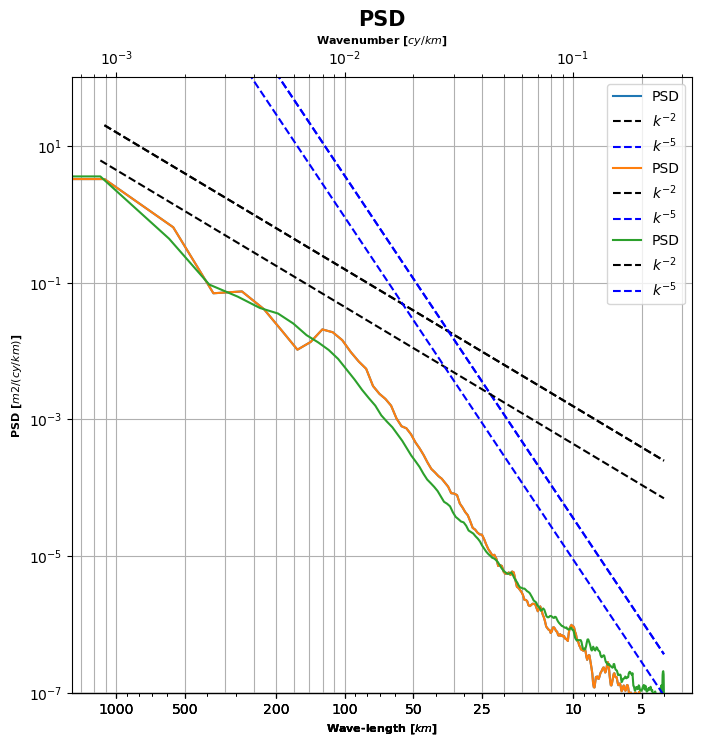

In [19]:
import matplotlib.pyplot as plt

fig, ax_ = plt.subplots(1, 1, figsize=(8, 8))
sp.plot_psd(ax_, freqs_mean, psd_mean, unit = "m2",psd_labels="PSD",title="PSD",savefig=True,plot_transparent=False)
sp.plot_psd(ax_, freqs_mean0, psd_mean0, unit = "m2",psd_labels="PSD",title="PSD",savefig=True,plot_transparent=False)
sp.plot_psd(ax_, freqs_mean_ori, psd_mean_ori, unit = "m2",psd_labels="PSD",title="PSD",savefig=True,plot_transparent=False)

In [ ]:
import DataPreprocessing_mod as dp

datasets_dict = dp.read_swot_ncfiles_S3subfolders(
        s3_folder,
        matching_cycles,
        endpoint_url,
        list_files,
        area)

In [8]:
%%time
import save_spect_json2 as ssj
import DataPreprocessing_mod as dp
prefix="GLO36V1"
bx=0
for feature in data["features"]:
    poly = shape(feature["geometry"])
    #lon_min, lat_min, lon_max, lat_max
    area = list(poly.bounds)
    area[0]=(area[0] + 360) % 360
    area[2]=(area[2] + 360) % 360
    area = tuple(area)
    print(area)

    phase = 'science'
    GEOMETRIES_FILE = f'KaRIn_2kms_{phase}_geometries.geojson'
    pass_numbers = dp2.swath_search(lon_min, lon_max, lat_min, lat_max, GEOMETRIES_FILE)
    list_files=dp.find_listdata(matching_cycles,prefix,bucket,s3_folder)


    datasets_dict = dp.read_swot_ncfiles_S3subfolders(
        s3_folder,
        matching_cycles,
        endpoint_url,
        list_files,
        area)
    
    has_converged, filled_datasets = dp.fill_nan(datasets_dict, varname = "ssh")

    segments_dict = sp.retrieve_segments(filled_datasets,FileType = "NetCDF",namevar="ssh")

    psd_dict, freqs_dict = sp.calculate_psd(segments_dict)
    # Calculate PSD Mean
    psd_mean, freqs_mean = sp.psd_mean_and_freq(psd_dict,freqs_dict)

    ssj.save_spect(("GS_box_"+str(bx)),"GLORYS36",season,freqs_mean,psd_mean,area[0],area[2],area[1],area[3],start_date,end_date)
    bx=bx+1
# It will be more faster if we load all the data and after select area
# I should save for every region or just one file

08_507_ included.
08_520_ included.
08_535_ included.
08_548_ included.
08_563_ included.
08_576_ included.
09_007_ included.
09_158_ included.
09_173_ included.
09_186_ included.
09_201_ included.
09_214_ included.
09_229_ included.
09_242_ included.
09_257_ included.
09_270_ included.
09_285_ included.
09_298_ included.
09_451_ included.
09_464_ included.
09_479_ included.
09_492_ included.
09_507_ included.
09_520_ included.
09_535_ included.
09_548_ included.
09_563_ included.
09_576_ included.
10_007_ included.
10_158_ included.
10_173_ included.
10_186_ included.
10_201_ included.
10_214_ included.
10_229_ included.
10_242_ included.
10_257_ included.
10_270_ included.
10_285_ included.
10_298_ included.
10_451_ included.
10_464_ included.
10_479_ included.
10_492_ included.
10_507_ included.
10_520_ included.
10_535_ included.
10_548_ included.
10_563_ included.
10_576_ included.
11_007_ included.
11_158_ included.
11_173_ included.
11_186_ included.
11_201_ included.
11_214_ in

/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/widetrax/Spectra.py:43: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for col in range(dataset.dims['num_pixels']):


JSON file created
09_046_ included.
09_061_ included.
09_074_ included.
09_089_ included.
09_102_ included.
09_117_ included.
09_130_ included.
09_145_ included.
09_158_ included.
09_173_ included.
09_186_ included.
09_339_ included.
09_352_ included.
09_367_ included.
09_380_ included.
09_395_ included.
09_408_ included.
09_423_ included.
09_436_ included.
09_451_ included.
09_464_ included.
09_479_ included.
10_046_ included.
10_061_ included.
10_074_ included.
10_089_ included.
10_102_ included.
10_117_ included.
10_130_ included.
10_145_ included.
10_158_ included.
10_173_ included.
10_186_ included.
10_339_ included.
10_352_ included.
10_367_ included.
10_380_ included.
10_395_ included.
10_408_ included.
10_423_ included.
10_436_ included.
10_451_ included.
10_464_ included.
10_479_ included.
11_046_ included.
11_061_ included.
11_074_ included.
11_089_ included.
11_102_ included.
11_117_ included.
11_130_ included.
11_145_ included.
11_158_ included.
11_173_ included.
11_186_ in

/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/widetrax/Spectra.py:43: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for col in range(dataset.dims['num_pixels']):


JSON file created
08_518_ included.
08_533_ included.
08_546_ included.
08_561_ included.
08_574_ included.
09_005_ included.
09_018_ included.
09_033_ included.
09_046_ included.
09_061_ included.
09_074_ included.
09_227_ included.
09_240_ included.
09_255_ included.
09_268_ included.
09_283_ included.
09_296_ included.
09_311_ included.
09_324_ included.
09_339_ included.
09_352_ included.
09_367_ included.
09_518_ included.
09_533_ included.
09_546_ included.
09_561_ included.
09_574_ included.
10_005_ included.
10_018_ included.
10_033_ included.
10_046_ included.
10_061_ included.
10_074_ included.
10_227_ included.
10_240_ included.
10_255_ included.
10_268_ included.
10_283_ included.
10_296_ included.
10_311_ included.
10_324_ included.
10_339_ included.
10_352_ included.
10_367_ included.
10_518_ included.
10_533_ included.
10_546_ included.
10_561_ included.
10_574_ included.
11_005_ included.
11_018_ included.
11_033_ included.
11_046_ included.
11_061_ included.
11_074_ in

/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/widetrax/Spectra.py:43: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for col in range(dataset.dims['num_pixels']):


JSON file created
08_518_ included.
08_546_ included.
08_561_ included.
08_574_ included.
09_005_ included.
09_018_ included.
09_033_ included.
09_046_ included.
09_061_ included.
09_089_ included.
09_117_ included.
09_184_ included.
09_212_ included.
09_240_ included.
09_255_ included.
09_268_ included.
09_283_ included.
09_296_ included.
09_311_ included.
09_324_ included.
09_339_ included.
09_367_ included.
09_395_ included.
09_490_ included.
09_518_ included.
09_546_ included.
09_561_ included.
09_574_ included.
10_005_ included.
10_018_ included.
10_033_ included.
10_046_ included.
10_061_ included.
10_089_ included.
10_117_ included.
10_184_ included.
10_212_ included.
10_240_ included.
10_255_ included.
10_268_ included.
10_283_ included.
10_296_ included.
10_311_ included.
10_324_ included.
10_339_ included.
10_367_ included.
10_395_ included.
10_490_ included.
10_518_ included.
10_546_ included.
10_561_ included.
10_574_ included.
11_005_ included.
11_018_ included.
11_033_ in

/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/widetrax/Spectra.py:43: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for col in range(dataset.dims['num_pixels']):


JSON file created
CPU times: user 30min 47s, sys: 20min 44s, total: 51min 32s
Wall time: 5h 53min 35s


In [46]:
area = list(poly.bounds)
area[0]=360-area[0]
area[2]=360-area[2]
area = tuple(area)
print(area)

(350.0, -50.0, 340.0, -40.0)


In [25]:
for poly in selected[5:]:
    #lon_min, lat_min, lon_max, lat_max
    area = list(poly.bounds)
    area = tuple(area)
    print(area)

(-50.0, 30.0, -40.0, 40.0)
(-50.0, 40.0, -40.0, 50.0)


## 💾 **Save Results and Information in JSON File**

## 📤 **Export Results to the S3 Endpoint** 

In [13]:
fs = s3fs.S3FileSystem( anon=True, endpoint_url="https://minio.lab.dive.edito.eu", use_ssl=False ) 

In [14]:
json_file = str(nom_region)+"_"+str(name_season)+"_"+str(model)+".json"
fs.put(json_file, "project-meom-ige/OMIP/")

[None]

In [16]:
fs